# GLD (SPDR Gold Shares)

In [1]:
import pandas as pd
import numpy as np
from mayavi import mlab
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.io import output_notebook

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "GLD_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

# 3D Analysis

#### Mayavi

In [3]:
# Create 3D data
x = np.linspace(categorized_df['Open'].min(), categorized_df['Open'].max(), 30)
y = np.linspace(categorized_df['Close'].min(), categorized_df['Close'].max(), 30)
z = np.linspace(min(categorized_df['Volume']), max(categorized_df['Volume']), 30)
x, y, z = np.meshgrid(x, y, z)

# Generate volumetric data
volume_field = np.sin(x**2 + y**2 + z**2)  # A simple test function is used

# Create Isosurface
mlab.contour3d(volume_field, contours=5, opacity=0.5)
mlab.title("Isosurface Plot")
mlab.show()

after running above code, this is the result: </br>
</br>
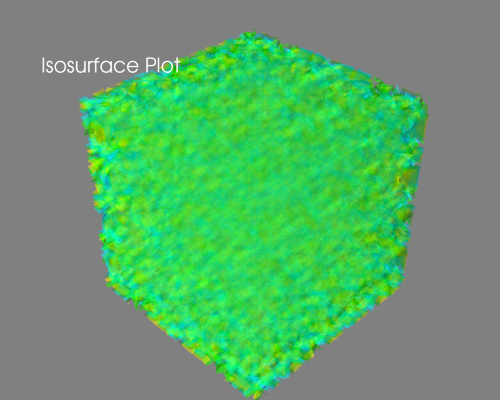


In [4]:
# 3D scatter data
x = categorized_df['Open']
y = categorized_df['Close']
z = categorized_df['Volume']

# Create Scatter Plot
mlab.points3d(x, y, z, z, scale_factor=0.1, colormap="cool")
mlab.title("Scatter Plot")
mlab.show()

after running above code, this is the result: </br>
</br>
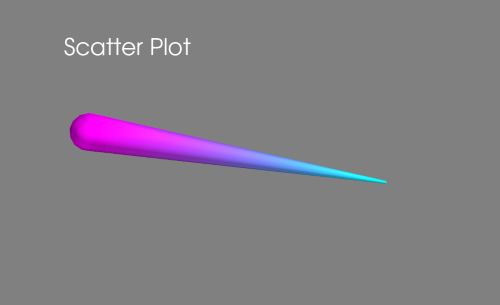


In [5]:
# Create a 3D grid
x = np.linspace(categorized_df['Open'].min(), categorized_df['Open'].max(), 30)
y = np.linspace(categorized_df['Close'].min(), categorized_df['Close'].max(), 30)
z = np.linspace(categorized_df['Volume'].min(), categorized_df['Volume'].max(), 30)
x, y, z = np.meshgrid(x, y, z)

# Volumetric data for visualization
volume_field = np.sin(np.sqrt(x**2 + y**2 + z**2))

# Ensure that the data is correctly 3D
assert volume_field.ndim == 3, "Input data must be 3D"

# Create slices
mlab.pipeline.image_plane_widget(mlab.pipeline.scalar_field(volume_field),
                                 plane_orientation='x_axes', slice_index=25)
mlab.pipeline.image_plane_widget(mlab.pipeline.scalar_field(volume_field),
                                 plane_orientation='y_axes', slice_index=25)
mlab.pipeline.image_plane_widget(mlab.pipeline.scalar_field(volume_field),
                                 plane_orientation='z_axes', slice_index=25)

mlab.title("Slice Plot")
mlab.show()

after running above code, this is the result: </br>
</br>
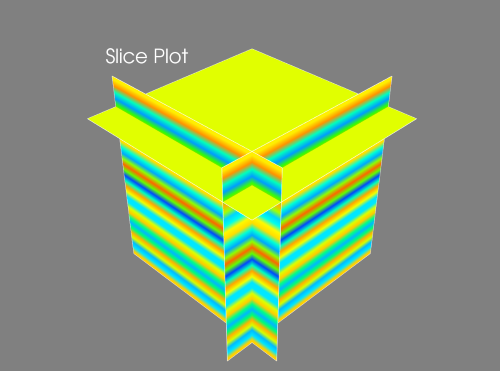

#### Bokeh => works with other libraries (also repetitive)

In [6]:
output_notebook()  # To render in Jupyter Notebook

# Create the data source
source = ColumnDataSource(data=dict(
    x=categorized_df['Open'],
    y=categorized_df['Close'],
    z=categorized_df['Volume'],
    color=categorized_df['Volume']
))

# Create a 3D scatter plot
p = figure(
    title="3D Scatter Plot with Bokeh", 
    x_axis_label="Open",
    y_axis_label="Close",
    width=800, 
    height=600)
p.scatter('x', 'y', size=10, source=source, color='blue', alpha=0.6)

# Show the plot
show(p)

Loading BokehJS ...

#### K3D-Jupyter => hard to work with

#### HoloViews => its diagrams was repetitive

#### PyVista => it was repetitive and hard to work with